# Hydroelectric Energy

## Learning goals

By the end of this lesson you should be able to:

- distinguish head, flow, power, and energy;
- calculate gross and net hydraulic power with consistent SI units;
- implement reusable Python functions with input checks;
- convert a flow time series into power and energy;
- interpret capacity factor, turbine limits, and pumped-storage efficiency;
- create and explain engineering plots rather than only calculate one number.

Hydropower converts the gravitational potential energy of water into shaft power and then electricity. Conventional storage plants, run-of-river plants, and pumped-storage plants use the same energy balance but have different operating constraints. Head and flow determine the resource; turbine-generator efficiency and equipment limits determine the electrical output. See the U.S. Department of Energy overview and turbine guidance [@doeHydropowerWorks; @doeHydroTurbines].

<!-- expanded-theory:hydro:start -->

## Physical description: water, elevation and electricity

Hydropower converts part of the mechanical energy of moving water into electricity. In the plants considered here, gravity drives water from a higher hydraulic-energy level to a lower one. A turbine converts part of that energy into shaft rotation, and a generator converts shaft power into electrical power. The ongoing hydrological cycle replenishes river flow, but the amount of water available at a particular location is finite and varies in time [@jica2011; @ifc2015].

A useful first description of a site therefore needs **both flow and head**. A large river is not necessarily a high-power site if little usable head is available. A mountain site may have high head but limited flow. Plant rating, annual energy and dependable dry-season output are separate design quantities. A station can have a large generator and a low capacity factor if water availability or operating constraints prevent continuous rated operation.

### Main system arrangements

| Arrangement | Defining feature | Main modelling implication |
|---|---|---|
| Run-of-river | Uses river flow with limited regulation in the simplified course model | Output closely follows available flow after required releases |
| Storage reservoir | Retains water so some inflow can be used later | Track storage, releases, spill and changing head chronologically |
| Diversion scheme | Conveys water through a canal, tunnel or penstock to gain useful head | Include conveyance losses and impacts along the bypassed river reach |
| Pumped storage | Uses electricity to lift water, then generates during release | Track both pumping consumption and recovered generation |

These categories can overlap: a run-of-river project may have some pondage, and a reservoir plant may also be part of a cascade. A pumped-storage scheme can have natural inflows as well as pumped water. Its total generation cannot automatically be treated as primary renewable production without appropriate accounting [@jica2011; @jrc2025hydro].

### Components and the flow path

The typical sequence is **intake → screen/trash rack → conveyance system → turbine → tailrace**, with **turbine shaft → generator → transformer → electrical network** on the energy-conversion side. Gates regulate flow; a spillway passes water that cannot or should not enter the turbines. An intake screen intercepts debris, while sediment-management facilities may be needed to limit abrasion and deposition.

The penstock conveys pressurized water to the turbine. A surge arrangement may be required to manage pressure transients. The tailrace returns water downstream. In a reaction-turbine installation, the draft tube is part of the pressure and velocity-energy recovery process; it is not an additional source of energy. Hydraulic design must consider the full water passage rather than only the turbine nameplate.

## Head, flow and the hydraulic energy balance

### What “head” means

Head is mechanical energy per unit **weight** of water, expressed in metres. For a steady incompressible flow, the elevation, pressure and velocity terms are

$$H=z+\frac{p}{\rho g}+\frac{v^2}{2g}.$$

$z$ is elevation relative to a common datum; $p$ is pressure using a consistent pressure reference; $v$ is mean flow velocity; $\rho$ is water density; and $g$ is gravitational acceleration. A difference in water-surface elevation is a useful approximation to gross head between large upstream and downstream water bodies when their pressure and velocity terms largely cancel. More general installations require the complete hydraulic-head difference.

The course uses

$$H_{net}=H_{gross}-h_{loss}.$$

The reference points must be specified consistently. Installation geometry and unrecovered outlet kinetic energy may matter as well as pipe friction; the JICA manual discusses effective head for different turbine arrangements. Do not subtract a loss twice if it has already been included in a supplied net-head value (Chapter 8) [@jica2011].

### Flow and volume are different quantities

Volume flow $Q$ is measured in m³/s. Water volume over an interval is $V=Q\Delta t$ for constant or interval-average flow, with time in seconds. Mass flow is $\dot m=\rho Q$ in kg/s. For example, 3 m³/s sustained for two hours moves $3\times7200=21{,}600$ m³; the water volume is not 6 m³.

The same distinction matters in reservoir routing. Electrical energy may be integrated using MW and hours, while the water balance uses m³/s and seconds. Keeping separate conversion factors in Python prevents a factor-of-3600 error.

### Deriving the power equation

A water mass $m$ descending through usable head $H$ has available mechanical energy $mgH$. For a continuously flowing mass rate $\dot m=\rho Q$, the available hydraulic power is

$$P_{hyd}=\rho gQH_{net}.$$

The electrical conversion chain gives

$$P_e=\eta_t\eta_g\rho gQH_{net},$$

where $\eta_t$ is turbine efficiency and $\eta_g$ is generator efficiency. A combined efficiency $\eta$ may include other explicitly identified losses. If station auxiliaries are not included in $\eta$, subtract their power separately when calculating net export. A quoted turbine efficiency must not be silently treated as the efficiency of the complete station [@jica2011; @ifc2015].

| Symbol | Definition | Unit used here |
|---|---|---|
| $Q$ | Flow actually passing through operating turbines | m³/s |
| $H_{gross}$, $H_{net}$ | Gross and usable turbine head | m |
| $h_{loss}$ | Hydraulic head dissipated or otherwise unavailable under the chosen boundary | m |
| $\rho$ | Water density, approximated as 1000 in these exercises | kg/m³ |
| $g$ | Gravitational acceleration, approximated as 9.81 | m/s² |
| $\eta_t$, $\eta_g$ | Conversion efficiencies | Fractions, not percentages in code |
| $P_e$, $P_r$ | Electrical output and electrical rating at a stated boundary | W or MW |

Dimensional check: $(\mathrm{kg/m^3})(\mathrm{m/s^2})(\mathrm{m^3/s})(\mathrm m)=\mathrm{kg\,m^2/s^3}=\mathrm W$. Divide by $10^6$ to obtain MW.

## Hydraulic losses and turbine operation

For a circular pipe, a useful friction model is the Darcy–Weisbach equation,

$$h_f=f_D\frac{L}{D}\frac{v^2}{2g},\qquad
v=\frac{Q}{A_p},\qquad A_p=\frac{\pi D^2}{4}.$$

$f_D$ is the dimensionless **Darcy** friction factor, $L$ and $D$ are pipe length and diameter in metres, and $A_p$ is pipe cross-sectional area. Do not substitute the numerically different Fanning friction factor without conversion. Fittings and transitions may be represented by $h_m=\sum K_jv^2/(2g)$ with appropriately defined local velocities. If geometry and coefficients are held fixed, losses scale approximately with $Q^2$. Thus doubling turbine flow need not double output: net head may fall as flow increases.

The Python exercises sometimes use a supplied loss value or an illustrative coefficient $h_{loss}=aQ^2$. That coefficient is not a universal property of hydropower. A real estimate needs geometry, roughness, fluid properties and a defensible hydraulic model.

### Turbine families

**Impulse turbines**, including Pelton machines, extract energy from a high-speed jet acting on the runner. **Reaction turbines**, including Francis and Kaplan/propeller arrangements, operate with pressure changes through the runner. Pelton machines are commonly associated with higher-head, lower-flow applications; Kaplan/propeller machines suit many lower-head, larger-flow settings; Francis machines occupy a broad intermediate range. These are qualitative tendencies, not rigid selection thresholds [@jica2011; @doeHydroTurbines].

Selection also depends on flow variation, rotational speed, cavitation, sediment, mechanical constraints and cost. Efficiency changes away from the design operating point. Minimum stable flow and turbine start/stop behavior mean that a constant-efficiency model may overstate output at very low discharge. Cavitation occurs when local pressure permits vapor cavities to form and subsequently collapse; it can damage components and constrain installation and operation.

The simple power cap $P=\min(\eta\rho gQH,P_r)$ is adequate for introductory energy calculations. It does not explicitly model gate position, turbine flow or pressure transients. At fixed head and efficiency, a corresponding flow limit is $Q_r=P_r/(\eta\rho gH)$. If water routing matters, allocate no more than that flow to the turbine and route the remainder to a bypass, spillway or storage.

## Water allocation, hydrology and storage

### Environmental releases before generation

An elementary allocation rule is

$$Q_{env,served}=\min(Q_{river},Q_{env,target}),$$
$$Q_{usable}=\max(Q_{river}-Q_{env,target},0).$$

If river flow is below the target, generation cannot create the missing environmental water. Record the shortfall separately. Actual environmental-flow rules may be seasonal, ecological and legally defined, and water may also be allocated to irrigation, water supply, flood control or navigation. A fixed reservation used in an exercise is an assumption, not a site prescription [@ifc2015].

### Hydrographs and flow-duration curves

A **hydrograph** retains the time sequence of flow. A **flow-duration curve** sorts flows from largest to smallest and plots them against an exceedance-frequency convention. The latter helps describe how often a flow is equalled or exceeded, but discards chronological information. The course uses plotting positions $r/(n+1)$ for descending rank $r$; other conventions exist and should be named.

A duration curve can support a simplified run-of-river energy estimate, but it cannot on its own determine reservoir operation or a sequence of shortages. Long-term assessment should cover wet and dry conditions, missing observations, upstream abstractions and changes in the catchment. A four-day exercise is not evidence of firm year-round production.

### Reservoir conservation and variable head

For a time step with constant or interval-average flows,

$$S_{t+1}=S_t+
(Q_{in}-Q_{turb}-Q_{env}-Q_{spill})\Delta t
-V_{evap}-V_{other}.$$

Storage $S$ and losses $V$ are in m³, flows are m³/s, and $\Delta t$ is seconds. Environmental flow and turbine release must be defined as distinct water paths; do not count the same discharge twice. A route with minimum storage or dead storage must limit withdrawals to water above that bound. Enforce $S_{min}\le S\le S_{max}$ and preserve mass balance at every step.

Reservoir level and tailwater can change, so head is generally a function of storage and discharge. Constant head is a useful simplification, particularly for short demonstrations, but can bias energy in a large drawdown. State whether within-step inflow can be used immediately and whether head is evaluated at the beginning, midpoint or end of the step.

## Pumped storage and energy accounting

Moving a volume $V$ upward through constant head $H$ stores approximately $E_{pot}=\rho gVH$ joules. Pumping and generation require separate efficiency directions:

$$E_{pump}=\frac{E_{pot}}{\eta_p},\qquad
E_{gen}=\eta_t\eta_gE_{pot}.$$

With the same head and water volume on both legs and no additional losses, $\eta_{RT}=\eta_p\eta_t\eta_g$. In a partial cycle, remaining water still contains stored energy; comparing generated energy with pumping input before accounting for that remaining storage gives an incomplete efficiency calculation. Pumped storage provides timing and flexibility services while consuming net electrical energy over a complete cycle [@jrc2025hydro].

## Worked calculation before coding

Take a synthetic river flow of 12 m³/s, environmental reservation of 2 m³/s, gross head of 30 m, hydraulic loss of 2 m and combined turbine-generator efficiency of 0.85.

1. Available turbine flow is $12-2=10$ m³/s.
2. Net head is $30-2=28$ m.
3. Uncapped electrical output is $1000(9.81)(10)(28)(0.85)=2{,}334{,}780$ W, or **2.33478 MW**.
4. A 2 MW generator limits exported power to **2 MW** under the simplified boundary.
5. Six hours at this output deliver **12 MWh**, not 12 MW.

If the model also routes water, calculate the flow needed for the capped output and handle the remaining available flow explicitly. Do not assume the generator cap eliminates water from the balance. This example omits separate auxiliary consumption and assumes unchanged conditions over six hours.

## Environmental context and the route to Python

Hydropower does not burn fuel in the turbine, but the project can affect river continuity, sediment transport, fish movement, inundated land, water quality and downstream flow timing. Reservoir greenhouse-gas behavior is site-specific; “renewable” does not mean zero life-cycle impact. The IFC guide is useful for connecting engineering calculations to project development and environmental assessment [@ifc2015].

Exercises 1–5 establish head, power, energy and water-volume units. Exercises 6–15 introduce equipment limits, variable flows, losses and duration curves. Exercises 16–20 require chronological storage and conservation checks. Read JICA Chapters 3 and 8 before these calculations; consult the supplied IFC guide for hydrology and project context, and Paish's technical review for further small-hydro background [@jica2011; @ifc2015; @paish2002hydro].


<!-- expanded-theory:hydro:end -->

## Concepts and equations: compact reference

### Gross head, head loss, and net head

The gross head is the upstream-to-downstream elevation or hydraulic-head difference. Friction and local losses reduce the head available at the turbine:

$$H_{net}=H_{gross}-h_{loss}$$

Always use $H_{net}$ in the plant power equation. Treating gross head as net head overestimates production.

### Power and energy

For water density $\rho$, gravity $g$, volume flow $Q$, net head $H_{net}$, and combined turbine-generator efficiency $\eta$:

$$P_e=\eta\rho gQH_{net}$$

| Quantity | SI unit |
|---|---|
| $\rho$ | kg/m$^3$ |
| $g$ | m/s$^2$ |
| $Q$ | m$^3$/s |
| $H$ | m |
| $P$ | W |

Power is an instantaneous rate. Energy over intervals $\Delta t_i$ is

$$E=\sum_i P_i\Delta t_i$$

If $P$ is in MW and $\Delta t$ in hours, $E$ is in MWh. For rated power $P_r$ and capacity factor $CF$ over $T$ hours:

$$E=P_r\,CF\,T,\qquad CF=\frac{E}{P_rT}$$

Capacity factor includes hydrology, outages, dispatch, and other constraints; it is not turbine efficiency.

### Equipment limits and storage

The generator limits electrical output:

$$P_{plant}=\min(P_e,P_r)$$

For pumped storage, round-trip efficiency compares recovered generation with pumping energy:

$$\eta_{RT}=\frac{E_{generated}}{E_{pumping}}$$

It is below one. Pumped storage shifts energy in time; it is not a net energy source.

## A tested Python model

In [1]:
import numpy as np
import matplotlib.pyplot as plt

RHO_WATER = 1000.0  # kg/m3
G = 9.81            # m/s2

def hydro_power_mw(flow_m3s, gross_head_m, efficiency=0.90,
                   head_loss_m=0.0, rated_power_mw=None):
    """Return hydroelectric power in MW for scalar or array inputs."""
    if not all(np.isfinite(np.asarray(value, dtype=float)).all() for value in [flow_m3s, gross_head_m, efficiency, head_loss_m]):
        raise ValueError("model inputs must be finite")
    flow = np.asarray(flow_m3s, dtype=float)
    net_head = np.asarray(gross_head_m, dtype=float) - head_loss_m
    if np.any(flow < 0):
        raise ValueError("flow_m3s must be non-negative")
    if np.any(np.asarray(head_loss_m) < 0):
        raise ValueError("head loss must be non-negative")
    if np.any(net_head < 0):
        raise ValueError("head loss cannot exceed gross head")
    if not 0 <= efficiency <= 1:
        raise ValueError("efficiency must be between 0 and 1")
    power = efficiency * RHO_WATER * G * flow * net_head / 1e6
    if rated_power_mw is not None:
        if not np.isfinite(rated_power_mw) or rated_power_mw < 0:
            raise ValueError("rated_power_mw must be non-negative")
        power = np.minimum(power, rated_power_mw)
    return float(power) if power.ndim == 0 else power

assert hydro_power_mw(0, 50) == 0
assert np.isclose(hydro_power_mw(100, 50, 0.90), 44.145)

The function combines basic Python ideas: arguments, defaults, conditionals, exceptions, NumPy arrays, and a return value.

## Worked time-series example

The following synthetic daily flows are teaching data, not a site assessment. A real study needs measured flow, an environmental-flow rule, a flow-duration curve covering wet and dry years, head-loss estimates, and an equipment-efficiency curve.

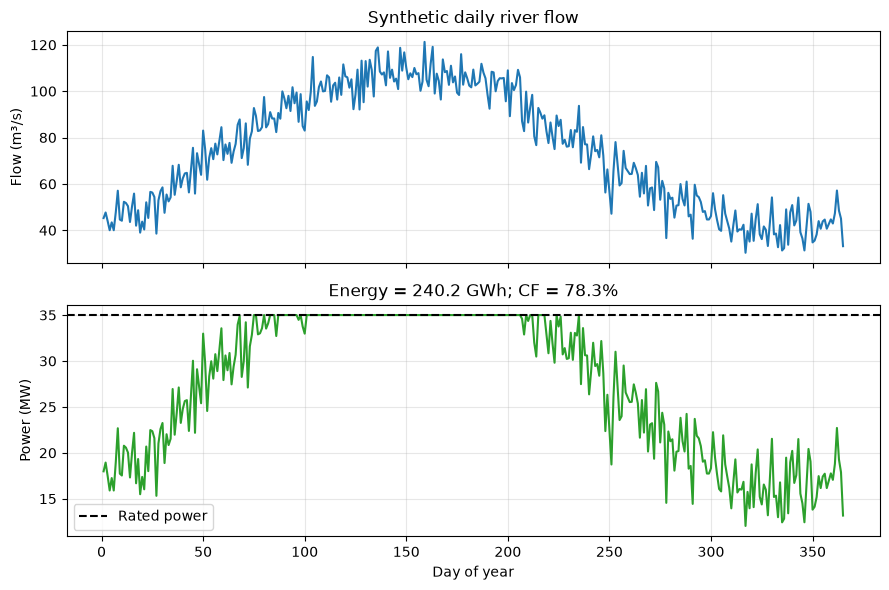

In [2]:
rng = np.random.default_rng(7)
days = np.arange(1, 366)
seasonal_flow = 75 + 35 * np.sin(2 * np.pi * (days - 60) / 365)
flow_m3s = np.clip(seasonal_flow + rng.normal(0, 7, len(days)), 10, None)

power_mw = hydro_power_mw(
    flow_m3s, gross_head_m=48, head_loss_m=3,
    efficiency=0.90, rated_power_mw=35,
)
energy_gwh = power_mw.sum() * 24 / 1000
capacity_factor = energy_gwh * 1000 / (35 * 8760)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(days, flow_m3s, color="tab:blue")
axes[0].set(ylabel="Flow (m³/s)", title="Synthetic daily river flow")
axes[1].plot(days, power_mw, color="tab:green")
axes[1].axhline(35, color="black", linestyle="--", label="Rated power")
axes[1].set(xlabel="Day of year", ylabel="Power (MW)",
            title=f"Energy = {energy_gwh:.1f} GWh; CF = {capacity_factor:.1%}")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()

The flat segments at 35 MW are generator clipping, not constant river flow. This is why resource and output plots should be viewed together.


[Download this complete chapter as a Jupyter notebook](hydroelectricEnergy.ipynb). In standard Jupyter viewers, answer headings and code are visible below each prompt; the book provides collapse controls.

## Chapter practice — 20 Python exercises

**5 easy · 10 medium · 5 hard.** Work through the exercises in order. All inputs are synthetic teaching data. Each solution is directly below its question and starts collapsed in the book. Open it after trying your own code. Each solution runs independently; run the full notebook from the first cell when studying the chapter. References identify the underlying concepts rather than copied textbook problems.

### Exercise 01 — Net head

**Difficulty:** Easy

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Gross head is 40 m and head loss 3 m. Calculate net head.

In [3]:
# Your solution for hydro exercise 01.

#### Step-by-step answer — Hydro 01

1. Enter gross head and hydraulic losses.
2. Subtract losses before calculating useful head.
3. Check the head is positive and report it.

In [4]:
# Step 1: Enter gross head and hydraulic losses.
gross, loss = 40, 3
# Step 2: Subtract losses before calculating useful head.
net = gross-loss
# Step 3: Check the head is positive and report it.
print(net,'m'); assert net == 37

37 m


**Interpretation:** Net head is 37 m; losses reduce rather than increase usable head.


### Exercise 02 — Electrical power

**Difficulty:** Easy

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Use Q=10 m³/s, net head 30 m, efficiency 0.9, density 1000 kg/m³ and g 9.81 m/s². Calculate MW.

In [5]:
# Your solution for hydro exercise 02.

#### Step-by-step answer — Hydro 02

1. Store parameters in SI units.
2. Convert hydraulic power to electricity and MW.
3. Check a hand-calculated result.

In [6]:
# Step 1: Store parameters in SI units.
q, head, eta, rho, g = 10,30,0.9,1000,9.81
# Step 2: Convert hydraulic power to electricity and MW.
power = rho*g*q*head*eta/1e6
# Step 3: Check a hand-calculated result.
print(power,'MW'); assert abs(power-2.6487)<1e-12

2.6487 MW


**Interpretation:** 2.6487 MW omits generator clipping.


### Exercise 03 — Daily hydro energy

**Difficulty:** Easy

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** A hydro generator averages 2 MW for 24 hours. Calculate MWh and kWh.

In [7]:
# Your solution for hydro exercise 03.

#### Step-by-step answer — Hydro 03

1. Enter average power and duration.
2. Integrate and convert energy units.
3. Verify and print both units.

In [8]:
# Step 1: Enter average power and duration.
power, hours = 2,24
# Step 2: Integrate and convert energy units.
mwh=power*hours; kwh=mwh*1000
# Step 3: Verify and print both units.
print(mwh,'MWh;',kwh,'kWh'); assert mwh==48 and kwh==48000

48 MWh; 48000 kWh


**Interpretation:** The power must be an interval average for this calculation.


### Exercise 04 — Environmental reservation

**Difficulty:** Easy

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** River flow is 8 m³/s and the environmental reservation is 3 m³/s. Calculate available turbine flow.

In [9]:
# Your solution for hydro exercise 04.

#### Step-by-step answer — Hydro 04

1. Enter river flow and reservation.
2. Reserve water before assigning turbine flow.
3. Check non-negativity and report the result.

In [10]:
# Step 1: Enter river flow and reservation.
river, reserve = 8,3
# Step 2: Reserve water before assigning turbine flow.
usable=max(river-reserve,0)
# Step 3: Check non-negativity and report the result.
print(usable,'m³/s'); assert usable==5

5 m³/s


**Interpretation:** This simplified reservation is not a site-specific environmental-flow prescription.


### Exercise 05 — Water volume

**Difficulty:** Easy

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** A turbine passes 3 m³/s for 2 hours. Calculate water volume.

In [11]:
# Your solution for hydro exercise 05.

#### Step-by-step answer — Hydro 05

1. Convert hours to seconds.
2. Integrate the constant flow rate.
3. Check and label the volume.

In [12]:
# Step 1: Convert hours to seconds.
seconds=2*3600
# Step 2: Integrate the constant flow rate.
volume=3*seconds
# Step 3: Check and label the volume.
print(volume,'m³'); assert volume==21600

21600 m³


**Interpretation:** Flow is volume per second; multiplying by hours without conversion is incorrect.


### Exercise 06 — Flow to power table

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** For river flows [2,5,10,20] m³/s, reserve 3, use head 25 m, eta 0.9, and a 2 MW rating. Tabulate usable flow and electrical MW.

In [13]:
# Your solution for hydro exercise 06.

#### Step-by-step answer — Hydro 06

1. Calculate usable flow for each river condition.
2. Apply the hydraulic model and generator cap.
3. Check dry and clipped cases and print a table.

In [14]:
import numpy as np
import pandas as pd
# Step 1: Calculate usable flow for each river condition.
river=np.array([2,5,10,20]); usable=np.maximum(river-3,0)
# Step 2: Apply the hydraulic model and generator cap.
power=np.minimum(1000*9.81*usable*25*0.9/1e6,2)
# Step 3: Check dry and clipped cases and print a table.
print(pd.DataFrame({'river_m3s':river,'usable_m3s':usable,'power_mw':power}))
assert power[0]==0 and power[-1]==2

   river_m3s  usable_m3s  power_mw
0          2           0  0.000000
1          5           2  0.441450
2         10           7  1.545075
3         20          17  2.000000


**Interpretation:** Capping power does not mean all available water must pass through the turbine.


### Exercise 07 — Generator flow limit

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Find maximum turbine flow for a 2 MW generator, net head 25 m and eta 0.9. Compare against available flow 12 m³/s.

In [15]:
# Your solution for hydro exercise 07.

#### Step-by-step answer — Hydro 07

1. Rearrange P=rho*g*Q*H*eta for Q.
2. Limit turbine flow to equipment capacity.
3. Recalculate power as a check.

In [16]:
# Step 1: Rearrange P=rho*g*Q*H*eta for Q.
q_limit=2e6/(1000*9.81*25*0.9)
# Step 2: Limit turbine flow to equipment capacity.
q_turbine=min(12,q_limit); bypass=12-q_turbine
# Step 3: Recalculate power as a check.
power=1000*9.81*q_turbine*25*0.9/1e6
print(q_limit,'m³/s limit;',bypass,'m³/s bypass'); assert abs(power-2)<1e-12

9.061048816400499 m³/s limit; 2.9389511835995012 m³/s bypass


**Interpretation:** Bypass is water not used for generation; environmental flow has already been reserved.


### Exercise 08 — Quadratic head loss

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** At Q=[2,4,6] m³/s use gross head 30 m and loss=0.1Q² m. Calculate net head and MW at eta 0.9.

In [17]:
# Your solution for hydro exercise 08.

#### Step-by-step answer — Hydro 08

1. Model the assumed flow-dependent loss.
2. Calculate head before calculating power.
3. Check head remains physically valid.

In [18]:
import numpy as np
# Step 1: Model the assumed flow-dependent loss.
q=np.array([2,4,6]); loss=0.1*q**2
# Step 2: Calculate head before calculating power.
head=30-loss; power=1000*9.81*q*head*0.9/1e6
# Step 3: Check head remains physically valid.
print(head,'m;',power,'MW'); assert np.all(head>0) and np.all(head<30)

[29.6 28.4 26.4] m; [0.5226768 1.0029744 1.3985136] MW


**Interpretation:** The loss coefficient is synthetic and needs hydraulic calibration for a real conduit.


### Exercise 09 — Monthly durations

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Mean output is 2 MW in January and February 2025. Use pandas calendar month lengths to calculate MWh for each month.

In [19]:
# Your solution for hydro exercise 09.

#### Step-by-step answer — Hydro 09

1. Create the two calendar months.
2. Multiply average output by actual month hours.
3. Verify the January and non-leap February results.

In [20]:
import pandas as pd
# Step 1: Create the two calendar months.
months=pd.date_range('2025-01-01',periods=2,freq='MS')
# Step 2: Multiply average output by actual month hours.
energy=2*24*months.days_in_month.to_numpy()
# Step 3: Verify the January and non-leap February results.
print(energy,'MWh'); assert list(energy)==[1488,1344]

[1488 1344] MWh


**Interpretation:** Constant monthly mean output does not imply equal monthly energy.


### Exercise 10 — Flow-duration ranking

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Sort daily flows [8,2,10,4] descending and assign exceedance plotting positions rank/(n+1).

In [21]:
# Your solution for hydro exercise 10.

#### Step-by-step answer — Hydro 10

1. Rank observed daily mean flows from largest to smallest.
2. Use the stated plotting-position convention.
3. Print paired values and check endpoints.

In [22]:
import numpy as np
# Step 1: Rank observed daily mean flows from largest to smallest.
flow=np.sort([8,2,10,4])[::-1]
# Step 2: Use the stated plotting-position convention.
exceedance=np.arange(1,len(flow)+1)/(len(flow)+1)
# Step 3: Print paired values and check endpoints.
print(list(zip(exceedance,flow)))
assert np.all(np.diff(flow)<=0) and np.allclose(exceedance,[.2,.4,.6,.8])

[(0.2, 10), (0.4, 8), (0.6, 4), (0.8, 2)]


**Interpretation:** A duration curve loses chronology and cannot directly route reservoir storage.


### Exercise 11 — Efficiency sensitivity

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** At Q 8 m³/s and net head 40 m, compare efficiencies 0.75,0.85,0.95. Print MW and the gain from lowest to highest.

In [23]:
# Your solution for hydro exercise 11.

#### Step-by-step answer — Hydro 11

1. Define conversion-efficiency scenarios.
2. Keep resource inputs fixed across scenarios.
3. Verify linear sensitivity and report gain.

In [24]:
import numpy as np
# Step 1: Define conversion-efficiency scenarios.
eta=np.array([0.75,0.85,0.95])
# Step 2: Keep resource inputs fixed across scenarios.
power=1000*9.81*8*40*eta/1e6
# Step 3: Verify linear sensitivity and report gain.
print(power,'MW; gain:',power[-1]-power[0],'MW')
assert np.allclose(power/power[0],eta/eta[0])

[2.3544  2.66832 2.98224] MW; gain: 0.62784 MW


**Interpretation:** Real turbine efficiency varies with operating point; these are comparison assumptions.


### Exercise 12 — Pumped-storage round trip

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Store 100000 m³ through 100 m head. With pump efficiency 0.85 and generation efficiency 0.9, find gravitational, input and recovered MWh.

In [25]:
# Your solution for hydro exercise 12.

#### Step-by-step answer — Hydro 12

1. Convert gravitational joules to MWh.
2. Account for pumping and generating conversion losses.
3. Check round-trip efficiency.

In [26]:
import numpy as np
# Step 1: Convert gravitational joules to MWh.
stored=1000*9.81*100000*100/3.6e9
# Step 2: Account for pumping and generating conversion losses.
input_energy=stored/0.85; output=stored*0.9
# Step 3: Check round-trip efficiency.
print(stored,input_energy,output,'MWh stored, input, output')
assert np.isclose(output/input_energy,0.85*0.9)

27.25 32.05882352941177 24.525000000000002 MWh stored, input, output


**Interpretation:** Storage shifts electricity and consumes net energy; it is not a new primary-energy source.


### Exercise 13 — Validate resource readings

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** For river flows [3,−1,missing,5] m³/s, flag invalid readings and report valid fraction without filling gaps.

In [27]:
# Your solution for hydro exercise 13.

#### Step-by-step answer — Hydro 13

1. Preserve the measured values and missing marker.
2. Replace only physically invalid negatives with missing.
3. Report coverage rather than a complete-period generation claim.

In [28]:
import pandas as pd
# Step 1: Preserve the measured values and missing marker.
flow=pd.Series([3,-1,None,5],dtype=float)
# Step 2: Replace only physically invalid negatives with missing.
clean=flow.mask(flow.lt(0))
# Step 3: Report coverage rather than a complete-period generation claim.
print(clean,'coverage:',clean.notna().mean()); assert clean.notna().sum()==2

0    3.0
1    NaN
2    NaN
3    5.0
dtype: float64 coverage: 0.5


**Interpretation:** Do not infer zero flow from an absent measurement.


### Exercise 14 — Environmental shortage

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Daily flows[1,4,7] m³/s must first provide up to 3 m³/s environmental release. Calculate release, shortage and remaining turbine flow.

In [29]:
# Your solution for hydro exercise 14.

#### Step-by-step answer — Hydro 14

1. Store daily mean flows and the reservation target.
2. Allocate available water before calculating shortages.
3. Reconcile water and print all three quantities.

In [30]:
import numpy as np
# Step 1: Store daily mean flows and the reservation target.
river=np.array([1,4,7]); target=3
# Step 2: Allocate available water before calculating shortages.
release=np.minimum(river,target); shortage=target-release; turbine=river-release
# Step 3: Reconcile water and print all three quantities.
assert np.array_equal(release+turbine,river)
print('Release, shortage, turbine m³/s:',release,shortage,turbine)
assert np.array_equal(shortage,[2,0,0])

Release, shortage, turbine m³/s: [1 3 3] [2 0 0] [0 1 4]


**Interpretation:** A shortage means the river cannot meet the target; no negative turbine flow is allowed.


### Exercise 15 — Plot a power-duration curve

**Difficulty:** Medium

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Daily flows[2,4,8,12,16] m³/s drive head 20 m, eta 0.9 and cap 2 MW with no reservation in this example. Plot ranked MW and calculate five-day MWh.

In [31]:
# Your solution for hydro exercise 15.

#### Step-by-step answer — Hydro 15

1. Calculate daily average electrical powers.
2. Sort only for the duration plot; integrate all equal-duration samples.
3. Plot the stated exceedance convention and check conservation of the sum.

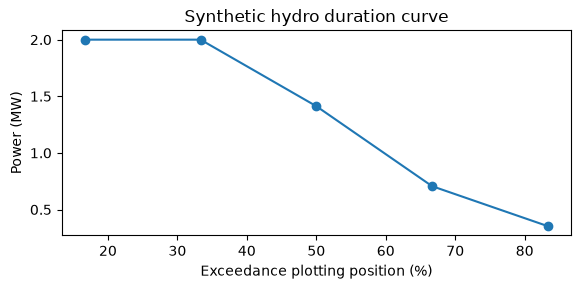

155.33088 MWh


In [32]:
import numpy as np
import matplotlib.pyplot as plt
# Step 1: Calculate daily average electrical powers.
power=np.minimum(1000*9.81*np.array([2,4,8,12,16])*20*0.9/1e6,2)
# Step 2: Sort only for the duration plot; integrate all equal-duration samples.
ranked=np.sort(power)[::-1]; energy=power.sum()*24
# Step 3: Plot the stated exceedance convention and check conservation of the sum.
fig,ax=plt.subplots(figsize=(6,3)); ax.plot(np.arange(1,6)/6*100,ranked,'o-')
ax.set(xlabel='Exceedance plotting position (%)',ylabel='Power (MW)',title='Synthetic hydro duration curve'); fig.tight_layout(); plt.show()
print(energy,'MWh'); assert np.isclose(ranked.sum()*24,energy)

**Interpretation:** Sorting preserves total energy for equal intervals but removes the order needed for storage simulation.


### Exercise 16 — Reservoir routing

**Difficulty:** Hard

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Route hourly inflows[2,0,8,16,0,0] m³/s; initial storage 20000 m³ and maximum 50000. Prioritise 1 m³/s environment, then up to 3 turbine; spill excess. Use head 20 m and eta 0.9. Check every water balance.

In [33]:
# Your solution for hydro exercise 16.

#### Step-by-step answer — Hydro 16

1. Set storage state and output records.
2. Allocate each hour of incoming water and spill overflow last.
3. Check total spill and final storage and report generated energy.

In [34]:
import numpy as np
# Step 1: Set storage state and output records.
storage=20000.; rows=[]
# Step 2: Allocate each hour of incoming water and spill overflow last.
for q in [2,0,8,16,0,0]:
    before=storage; water=storage+q*3600
    environmental=min(water,3600); water-=environmental
    turbine=min(water,3*3600); water-=turbine
    spill=max(water-50000,0); storage=water-spill
    assert np.isclose(before+q*3600,storage+environmental+turbine+spill)
    energy=1000*9.81*turbine*20*0.9/3.6e9
    rows.append((storage,spill,energy,3600-environmental))
# Step 3: Check total spill and final storage and report generated energy.
print('Final storage:',storage,'m³; total generation:',sum(r[2] for r in rows),'MWh')
assert storage==21200 and sum(r[1] for r in rows)==7600

Final storage: 21200.0 m³; total generation: 3.09996 MWh


**Interpretation:** Within-hour inflow is immediately available; head is constant and evaporation is omitted.


### Exercise 17 — Storage-dependent head

**Difficulty:** Hard

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Route inflows[2,0,3] m³/s for three hours from 20000 m³. Withdraw up to 2 m³/s, no spill limit. Use beginning-of-step head H=10+S/10000 m and eta 0.9; compare with constant 12 m.

In [35]:
# Your solution for hydro exercise 17.

#### Step-by-step answer — Hydro 17

1. Initialise storage and energy counters.
2. Use beginning-of-step head and limit withdrawal to available water.
3. Compare model outputs and verify the final storage.

In [36]:
import numpy as np
# Step 1: Initialise storage and energy counters.
storage=20000.; variable_energy=0.; fixed_energy=0.
# Step 2: Use beginning-of-step head and limit withdrawal to available water.
for inflow in [2,0,3]:
    before=storage; head=10+before/10000
    available=before+inflow*3600; volume=min(2*3600,available)
    storage=available-volume
    variable_energy+=1000*9.81*volume*head*0.9/3.6e9
    fixed_energy+=1000*9.81*volume*12*0.9/3.6e9
    assert np.isclose(before+inflow*3600,storage+volume)
# Step 3: Compare model outputs and verify the final storage.
print(variable_energy,fixed_energy,'MWh variable/fixed head')
assert storage==16400 and variable_energy<fixed_energy

0.62297424 0.635688 MWh variable/fixed head


**Interpretation:** Beginning-of-step head is a numerical approximation; smaller time steps may be needed for rapid level changes.


### Exercise 18 — Environmental-flow trade-off

**Difficulty:** Hard

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** For daily river flows[2,5,8,12] m³/s, compare reservations 1,3,5 m³/s, head 30 m, eta 0.9, cap 2 MW. Calculate four-day energy and environmental-shortage volume.

In [37]:
# Your solution for hydro exercise 18.

#### Step-by-step answer — Hydro 18

1. Keep the same river observations for every policy scenario.
2. Apply reservation, clipping and interval conversions.
3. Check the energy trade-off and report units.

In [38]:
import numpy as np
# Step 1: Keep the same river observations for every policy scenario.
river=np.array([2,5,8,12]); results=[]
# Step 2: Apply reservation, clipping and interval conversions.
for reserve in [1,3,5]:
    usable=np.maximum(river-reserve,0)
    power=np.minimum(1000*9.81*usable*30*0.9/1e6,2)
    shortage=np.maximum(reserve-river,0).sum()*86400
    results.append((reserve,power.sum()*24,shortage))
# Step 3: Check the energy trade-off and report units.
print('Reservation m³/s, energy MWh, shortage m³:',results)
assert np.all(np.diff([r[1] for r in results])<=0)

Reservation m³/s, energy MWh, shortage m³: [(1, 124.28256, 0), (3, 92.49816, 86400), (5, 63.568799999999996, 259200)]


**Interpretation:** The model compares water allocation, not ecological adequacy or regulatory compliance.


### Exercise 19 — Search a generator rating

**Difficulty:** Hard

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** Flows[2,4,8,12] m³/s last 24 h each, head 30 m and eta 0.9. Choose the smallest candidate rating[1,2,3,4] MW that captures 95% of uncapped energy.

In [39]:
# Your solution for hydro exercise 19.

#### Step-by-step answer — Hydro 19

1. Calculate the uncapped electrical resource.
2. Evaluate retained energy for each candidate rating.
3. Select and verify the first feasible rating.

In [40]:
import numpy as np
# Step 1: Calculate the uncapped electrical resource.
available=1000*9.81*np.array([2,4,8,12])*30*0.9/1e6
# Step 2: Evaluate retained energy for each candidate rating.
results=[(r,np.minimum(available,r).sum()/available.sum()) for r in [1,2,3,4]]
# Step 3: Select and verify the first feasible rating.
best=next(row for row in results if row[1]>=0.95)
print('MW rating, retained energy fraction:',best); assert best[0]==3

MW rating, retained energy fraction: (3, 0.9740888854038701)


**Interpretation:** This is an energy-capture criterion; construction cost and seasonal hydrology are not represented.


### Exercise 20 — Pumped-storage dispatch and water balance

**Difficulty:** Hard

**Reference:** Hydropower equations and generation planning: [@jica2011], Chapters 3 and 8; hydrology and environmental flow [@ifc2015], Chapters 7 and 12.

**Task:** An upper reservoir starts empty with capacity 10000 m³ and head 100 m. Pump with 1 MW for two hours at 85%, then generate for two hours at up to 0.7 MW and 90%. Track water and electricity.

In [41]:
# Your solution for hydro exercise 20.

#### Step-by-step answer — Hydro 20

1. Set state and energy totals at constant head.
2. Limit pumping by space and generation by available water.
3. Account for remaining stored energy as well as conversion losses.

In [42]:
import numpy as np
# Step 1: Set state and energy totals at constant head.
storage=0.; used=0.; recovered=0.; joules_per_m3=1000*9.81*100
# Step 2: Limit pumping by space and generation by available water.
for action in ['pump','pump','generate','generate']:
    before=storage
    if action=='pump':
        volume=min(1e6*3600*0.85/joules_per_m3,10000-storage)
        storage+=volume; used+=volume*joules_per_m3/0.85/3.6e9
    else:
        volume=min(0.7e6*3600/(joules_per_m3*0.9),storage)
        storage-=volume; recovered+=volume*joules_per_m3*0.9/3.6e9
    assert 0<=storage<=10000 and abs(storage-before)<=10000
# Step 3: Account for remaining stored energy as well as conversion losses.
stored_equivalent=storage*joules_per_m3*0.9/3.6e9
print(used,recovered,stored_equivalent,'MWh pumping, exported, recoverable remaining')
assert np.isclose(recovered+stored_equivalent,used*0.85*0.9)

2.0 1.4 0.1300000000000002 MWh pumping, exported, recoverable remaining


**Interpretation:** The final reservoir need not be empty; recovered/pumped energy over a partial cycle is not full round-trip efficiency.


## Common mistakes

- Using gross head when the equation requires net head.
- Confusing efficiency with capacity factor.
- Multiplying MW by seconds and labelling the result MWh.
- Ignoring generator clipping or environmental-flow requirements.
- Applying capacity factor to power that is already a time average.
- Treating pumped storage as a source of net electricity.

## Check your understanding

Continue with the [hydropower quiz and Python challenge](../section7/renewableEnergyquizzes/hydroelectricEnergy.md).

## References used in this notebook

- **paish2002hydro:** Paish, Oliver. Small Hydro Power: Technology and Current Status (2002). 
- **doeHydropowerWorks:** U.S. Department of Energy. How Hydropower Works (2025). https://www.energy.gov/cmei/water/how-hydropower-works
- **doeHydroTurbines:** U.S. Department of Energy. Types of Hydropower Turbines (2025). https://www.energy.gov/cmei/water/types-hydropower-turbines
- **jica2011:** Japan International Cooperation Agency. Guideline and Manual for Hydropower Development, Vol. 2: Small Scale Hydropower (2011). 
- **ifc2015:** International Finance Corporation. Hydroelectric Power: A Guide for Developers and Investors (2015). 
- **jrc2025hydro:** Quaranta, Emanuele and Georgakaki, Aliki and Letout, Sylvain and Mountraki, Agnieszka and Ince, Ebru and others. Clean Energy Technology Observatory: Hydropower and Pumped Storage Hydropower in the European Union — 2025 Status Report on Technology Development, Trends, Value Chains and Markets (2025). 